## Part 1: Tensors, Autograd and The 'Forward Pass'

In [1]:
import torch

batch_size = 4
channels = 3
height = 64
width = 64

images = torch.rand(batch_size, channels, height, width)
print(images)
print(images.shape)

tensor([[[[5.3620e-01, 6.6338e-01, 4.4357e-01,  ..., 1.5189e-02,
           6.2158e-01, 1.6549e-01],
          [4.9509e-01, 3.8417e-02, 4.4474e-01,  ..., 8.8676e-01,
           6.9473e-01, 1.6207e-01],
          [5.2926e-01, 7.8964e-01, 4.2303e-01,  ..., 4.5478e-01,
           4.7098e-01, 2.4094e-01],
          ...,
          [9.1473e-01, 4.5842e-02, 9.2573e-01,  ..., 8.7684e-01,
           8.3531e-02, 9.9696e-02],
          [6.0129e-01, 1.7752e-01, 8.3826e-01,  ..., 8.6281e-01,
           2.0699e-01, 2.1836e-01],
          [2.0416e-01, 9.7414e-01, 3.9660e-02,  ..., 7.2417e-01,
           1.4895e-01, 8.9645e-01]],

         [[6.8942e-01, 8.7513e-02, 1.5563e-01,  ..., 1.0911e-01,
           2.7256e-01, 1.1348e-01],
          [7.5521e-01, 1.5962e-01, 5.1598e-01,  ..., 8.9663e-02,
           1.8463e-01, 7.3277e-02],
          [7.4593e-01, 8.3914e-01, 6.1464e-01,  ..., 4.8770e-01,
           9.2447e-01, 3.3906e-01],
          ...,
          [1.2100e-01, 1.4359e-01, 7.7712e-01,  ..., 1.9549

In [2]:
flattened_images = torch.flatten(images, start_dim=1)   # Included start_din = 1 cause we do not want to flatten the batch size
print(flattened_images)
print(flattened_images.shape)   # (Batch, Channel, Height, Width) -> (Batch, Flattened features)


tensor([[0.5362, 0.6634, 0.4436,  ..., 0.7933, 0.6339, 0.6160],
        [0.3267, 0.8065, 0.5962,  ..., 0.5369, 0.2836, 0.1379],
        [0.2205, 0.1314, 0.4473,  ..., 0.4902, 0.3752, 0.6261],
        [0.0742, 0.5679, 0.5180,  ..., 0.2612, 0.9334, 0.9638]])
torch.Size([4, 12288])


In [3]:
# Rudementary forward pass

batch_size = 4
input_features = 8
output_features = 5

X = torch.randn(batch_size, input_features)
W = torch.randn(output_features, input_features)
B = torch.randn(output_features)

Y = torch.matmul(X, W.T) + B

print("Input Shape:", X.shape)
print("Weight Shape:", W.shape)
print("Bias Shape:", B.shape)
print("Output Shape:", Y.shape)
print("\nOutput:\n", Y)



Input Shape: torch.Size([4, 8])
Weight Shape: torch.Size([5, 8])
Bias Shape: torch.Size([5])
Output Shape: torch.Size([4, 5])

Output:
 tensor([[-7.5312, -0.3490,  0.7888, -0.1295, -1.1191],
        [ 2.0059, -2.7826, -0.5729,  0.6387, -5.5472],
        [ 1.1671, -2.9155,  0.7963, -2.2112, -5.0999],
        [ 1.5503, -0.5092, -0.3623, -4.4310, -7.7090]])


In [4]:
# Autograd Mechanics

import torch.nn.functional as F

W = W.requires_grad_()
B = B.requires_grad_()

Y = torch.matmul(X, W.T) + B
print('Forward Output:\n', Y)

target = torch.randn_like(Y)

loss = F.mse_loss(Y, target=target)
print('Loss: ', loss.item())

loss.backward() # Doing backward pass for gradient generation

print('Gradient of W:\n', W.grad)
print("Gradient shape:", W.grad.shape)
print("Gradient of B:\n", B.grad)

Forward Output:
 tensor([[-7.5312, -0.3490,  0.7888, -0.1295, -1.1191],
        [ 2.0059, -2.7826, -0.5729,  0.6387, -5.5472],
        [ 1.1671, -2.9155,  0.7963, -2.2112, -5.0999],
        [ 1.5503, -0.5092, -0.3623, -4.4310, -7.7090]], grad_fn=<AddBackward0>)
Loss:  13.738946914672852
Gradient of W:
 tensor([[-1.0912, -1.1246,  0.3102, -0.1016, -0.3532, -0.2964,  1.1091,  1.4341],
        [ 0.3636,  1.1898,  0.4905, -0.5791,  0.6843, -0.1893, -0.4910, -0.7326],
        [ 0.3246,  0.2332,  0.1784,  0.0546,  0.2913, -0.0268, -0.3104, -0.2964],
        [ 0.3261,  0.4511,  0.7947, -0.1608,  0.8305, -0.2870, -0.1631, -0.2287],
        [ 0.8145,  1.9131,  2.1702, -0.9486,  2.2926, -0.8394, -0.6796, -0.9329]])
Gradient shape: torch.Size([5, 8])
Gradient of B:
 tensor([-0.2549, -0.9011, -0.0976, -0.6457, -2.3233])


1. Why we flatten images before feeding them into a standard Feed Forward Network 
(ANN)?

We flatten the images before feeding it into a standard Feed Forward Network (ANN) because of the fact that a fully connected layer of ANN expects a 1-D feature vector per sample i.e Shape => (N, Features) and normally an image tensor has a structure of (Batch, Channel, Height, Width) so we reshape it.
As a dense layer performs matrix multiplication `Y = XW^T + B`, it requires X to have a shape of (batch, features) as matrix multiplication cannot operate directly on 2D spatial grids. The consequences of this are that the spatial structure and relationship between pixels is lost as each pixel is now treated as an independent entity.

2. The difference between a Tensor and a NumPy array regarding the computational graph. 

A tensor and a NumPy array may look similar because both store multidimensional numerical data but they differ in how the computations are handled. A tensor can participate in a computational graph when `requires_grad=True` is enabled. This means that PyTorch records every mathematical operation applied to a tensor. Later, when `.backward()` is called, it automatically applies reverse-mode automatic differentiation to compute gradients such as `∂Loss/∂parameters`, which is essential for training neural networks using backpropagation. In contrast to this, a NumPy array only stores numerical values and immediately forgets how those values were produced, i.e. it has no computational graph function and thus cannot track operations performed or compute gradients automatically.

## Part 2: FFNN, Loss and Gradient Descent (The Training Loop)

In [5]:
# Function created on a seperate python file (attached)
import torch.nn.functional as F
from SimpleANN import SimpleANN

model = SimpleANN(input_features=784, hidden1=128, hidden2=64, output_features=10)

x = torch.randn(20, 1, 28, 28)
output = F.softmax(model(x), dim=1)
# Output is not that important as I am working on random numbers anyway
print(output.shape)

model_binary = SimpleANN(input_features=784, hidden1=128, hidden2=64, output_features=1)
output2 = F.softmax(model(x), dim=1)

print(output2.shape)

torch.Size([20, 10])
torch.Size([20, 10])


ReLU enables effective gradient propagation and feature extraction inside the network as we are preventing vanishing gradient issue, improving computational efficiency and also doing sparse activation for better feature learning, while Sigmoid/Softmax converts the final linear outputs into probabilistic predictions compatible with classification loss functions meaning for Binary Classification, Sigmoid is used with Binary Cross Entropy Loss as it produces a probability and for Multi-class Classification, Softmax is used with CrossEntropyLoss as it converts logits into probability distributions.

In [6]:
import torch.nn as nn

batch_size = 20
x = torch.randn(batch_size, 1, 28, 28)
y = torch.randint(0,10,(batch_size,))

# For Multi-class classification (directly requires logits)
criterion = nn.CrossEntropyLoss()

In [7]:
model = SimpleANN(784, 128, 64, 10)   # As we want raw logit output [using nn.CrossEntropyLoss]
lr = 0.01

for epoch in range(5):
    output = model.forward(x)
    loss = criterion(output, y)
    loss.backward()

    with torch.no_grad():
        for params in model.parameters():
            params -= lr*params.grad

    model.zero_grad()

    print(f'Epoch {epoch+1} | Loss: {loss.item():.4f}')

Epoch 1 | Loss: 2.2982
Epoch 2 | Loss: 2.2853
Epoch 3 | Loss: 2.2727
Epoch 4 | Loss: 2.2602
Epoch 5 | Loss: 2.2480


For multi-class classification, we don't just want the model to output the correct label, we want the model to output a high probability for the correct class and low probabilities for other class. For this we use Cross-Entropy Loss. Our network outputs the raw logits and cross entropy loss converts them into probabilities using softmax function, thus the model predicts a probability distribution over classes.

As the loss computes to `Loss = -log(P(correct class))` [CrossEntropyLoss only cares about the probability assigned to true class], the more confidently wrong the model is, the harsher the punishment (the loss value). 

1. What happened to the Loss value over 5 epochs? (Did it minimize?)

During the training, each epoch performs `θ new = θ old - (Learning Rate x Gradient)`, so the parameters move in the direction that reduces the error. From the results printed above, we can see that the loss is minimized as the epochs increase. In a nutshell, yes the loss did minimize.

2. How changing the Learning Rate affects the speed of loss minimization.

The learning rate determines how big a step the model takes while updating weights during gradient descent, which directly affects how quickly the loss decreases. A very small learning rate makes the loss reduce slowly because updates to the model are tiny, while a properly chosen learning rate allows the loss to drop quickly and smoothly. If the learning rate is too large, the updates overshoot the minimum, causing the loss to oscillate or even increase, preventing the model from converging. In the case of high learning rate leading to oscillation, no matter the number of epochs you take, the model fails to converge i.e. to minimize the loss.

## Part 3: Regularization and Dropout

In [8]:
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt

# Converting images into PyTorch tensor
transform = transforms.ToTensor()

train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

small_train_sub = Subset(train_dataset_full, range(100))

train_size = 80
val_size = 20
train_dataset, val_dataset = random_split(small_train_sub, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16)
test_dataloader = DataLoader(test_dataset,batch_size=128)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
from torchmetrics.classification import MulticlassAccuracy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, train_dataloader, val_dataloader, no_epochs, optimizer, criterion):
    model = model.to(device)

    train_metric = MulticlassAccuracy(num_classes=10).to(device)
    val_metric   = MulticlassAccuracy(num_classes=10).to(device)

    epochs = no_epochs
    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):
        model.train()
        train_metric.reset()

        for x,y in train_dataloader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)
            train_metric.update(preds,y)

        train_acc = train_metric.compute().item()

        model.eval()
        val_metric.reset()

        with torch.no_grad():
            for x,y in val_dataloader:
                x = x.to(device)
                y = y.to(device)

                logits = model(x)
                preds = torch.argmax(logits, dim=1)
                val_metric.update(preds, y)

        val_acc = val_metric.compute().item()

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(f'Epoch {epoch+1} | Train Accuracy: {train_acc:.4f} | Validaion Accuracy: {val_acc:.4f}')

    # Plotting
    plt.figure(figsize=(8,5))
    plt.plot(train_acc_list, label="Training Accuracy")
    plt.plot(val_acc_list, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Graph")
    plt.legend()
    plt.show()


c:\Users\aryan\anaconda3\envs\nlp_env_forge\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1 | Train Accuracy: 0.1222 | Validaion Accuracy: 0.2315
Epoch 2 | Train Accuracy: 0.4106 | Validaion Accuracy: 0.4352
Epoch 3 | Train Accuracy: 0.6943 | Validaion Accuracy: 0.6204
Epoch 4 | Train Accuracy: 0.7245 | Validaion Accuracy: 0.5833
Epoch 5 | Train Accuracy: 0.7249 | Validaion Accuracy: 0.6250
Epoch 6 | Train Accuracy: 0.7652 | Validaion Accuracy: 0.6250
Epoch 7 | Train Accuracy: 0.8000 | Validaion Accuracy: 0.6583
Epoch 8 | Train Accuracy: 0.8333 | Validaion Accuracy: 0.6250
Epoch 9 | Train Accuracy: 0.8625 | Validaion Accuracy: 0.6583
Epoch 10 | Train Accuracy: 0.8875 | Validaion Accuracy: 0.7583
Epoch 11 | Train Accuracy: 0.9542 | Validaion Accuracy: 0.7583
Epoch 12 | Train Accuracy: 0.9542 | Validaion Accuracy: 0.7083
Epoch 13 | Train Accuracy: 1.0000 | Validaion Accuracy: 0.7583
Epoch 14 | Train Accuracy: 1.0000 | Validaion Accuracy: 0.7583
Epoch 15 | Train Accuracy: 1.0000 | Validaion Accuracy: 0.7583
Epoch 16 | Train Accuracy: 1.0000 | Validaion Accuracy: 0.7583
E

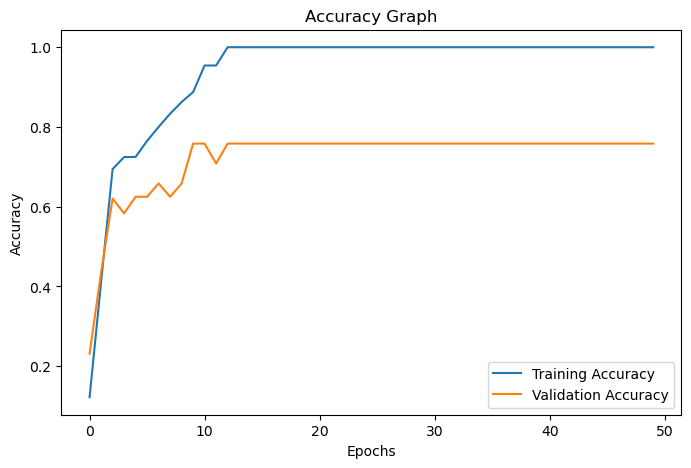

In [11]:
train(model=model, train_dataloader=train_dataloader, val_dataloader=val_dataloader, no_epochs=50, optimizer=optimizer, criterion=criterion)

In [12]:
import torch
import torch.nn as nn

class SimpleANN_Dropout(nn.Module):
    def __init__(self, input_features, hidden1, hidden2, output_features, p):
        super(SimpleANN_Dropout, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_features, hidden1),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(hidden2, output_features),
        )

    def forward(self, x):

        return self.model(x)

Epoch 1 | Train Accuracy: 0.1333 | Validaion Accuracy: 0.1389
Epoch 2 | Train Accuracy: 0.1476 | Validaion Accuracy: 0.1944
Epoch 3 | Train Accuracy: 0.1000 | Validaion Accuracy: 0.1389
Epoch 4 | Train Accuracy: 0.1758 | Validaion Accuracy: 0.1667
Epoch 5 | Train Accuracy: 0.2111 | Validaion Accuracy: 0.2222
Epoch 6 | Train Accuracy: 0.2468 | Validaion Accuracy: 0.2222
Epoch 7 | Train Accuracy: 0.1939 | Validaion Accuracy: 0.1667
Epoch 8 | Train Accuracy: 0.3003 | Validaion Accuracy: 0.2037
Epoch 9 | Train Accuracy: 0.2892 | Validaion Accuracy: 0.3519
Epoch 10 | Train Accuracy: 0.2951 | Validaion Accuracy: 0.3519
Epoch 11 | Train Accuracy: 0.3537 | Validaion Accuracy: 0.3519
Epoch 12 | Train Accuracy: 0.3483 | Validaion Accuracy: 0.4074
Epoch 13 | Train Accuracy: 0.3530 | Validaion Accuracy: 0.4074
Epoch 14 | Train Accuracy: 0.3659 | Validaion Accuracy: 0.5185
Epoch 15 | Train Accuracy: 0.3503 | Validaion Accuracy: 0.5741
Epoch 16 | Train Accuracy: 0.4653 | Validaion Accuracy: 0.6296
E

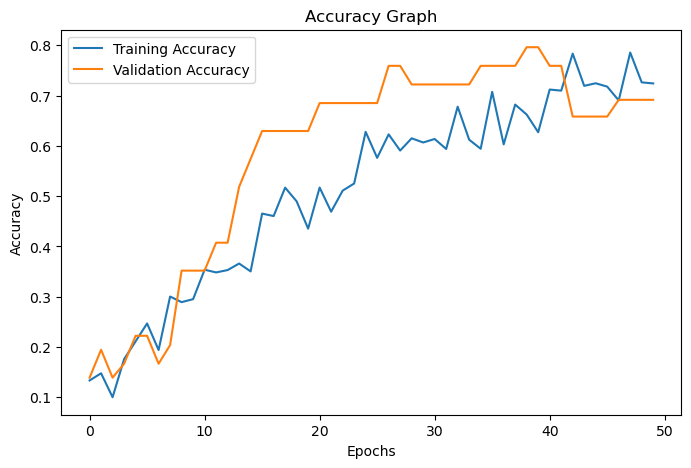

In [17]:
model_dropout = SimpleANN_Dropout(784, 128, 64, 10, 0.5)
optimizer = torch.optim.Adam(model_dropout.parameters(), lr=3e-4)
train(model=model_dropout, train_dataloader=train_dataloader, val_dataloader=val_dataloader, no_epochs=50, optimizer=optimizer, criterion=criterion)

What Dropout does is that it randomly turns off some neurons during each training step, so the network cannot rely on specific neuron combinations to make a prediction. Instead, each neuron must learn features that are useful on their own, leading the model to capture general patterns (like shapes or strokes) rather than memorizing exact training examples. This reduces co-adaptation between neurons and helps the network generalize better to unseen data as we can see from the plots of training accuracy and validation accuracy curves of ANN with no dropout and ANN with dropout above.

1. Did Dropout slow down the training accuracy?
   
Yes, training accuracy increased more slowly and reached a lower maximum when Dropout was used. Because some neurons are randomly disabled during each update, the model cannot memorize the training data as easily, so learning appears slower.

2. Did Dropout improve the validation accuracy?

Yes, validation accuracy improved compared to the non-dropout model. By preventing the network from relying on specific neuron combinations, Dropout reduced overfitting and allowed the model to generalize better to unseen data by making sure that each neuron learns to capture features instead of model meomorising the the neuron combinations leading to better generalization.

## Part 4: Fundamentals of CNN (Convolutional Neural Networks)

Flatenning converts a 2D image into a 1D vector (28 x 28 -> 784). In this process, the relative positions of the pixels are lost. In the original image, each pixel had spatial meaning that together formed various features like shapes, curves, edges etc. After flatenning all those neighbouring relationships cease to exist, i.e. the two adjacent pixels in a flattened vector are not necessarily adjacent to each other.
This makes to model to not recognize structures in the image and it only sees them as independent intensity values. This leads the network to learn the spatial patterns from scratch using weights, which is inefficient and harms generalization.

Epoch 1 | Train Accuracy: 0.1125 | Validaion Accuracy: 0.1111
Epoch 2 | Train Accuracy: 0.1569 | Validaion Accuracy: 0.1111
Epoch 3 | Train Accuracy: 0.1345 | Validaion Accuracy: 0.1111
Epoch 4 | Train Accuracy: 0.1254 | Validaion Accuracy: 0.1667
Epoch 5 | Train Accuracy: 0.2185 | Validaion Accuracy: 0.3056
Epoch 6 | Train Accuracy: 0.2293 | Validaion Accuracy: 0.2778
Epoch 7 | Train Accuracy: 0.2529 | Validaion Accuracy: 0.4074
Epoch 8 | Train Accuracy: 0.2495 | Validaion Accuracy: 0.4630
Epoch 9 | Train Accuracy: 0.3574 | Validaion Accuracy: 0.4074
Epoch 10 | Train Accuracy: 0.2638 | Validaion Accuracy: 0.4630
Epoch 11 | Train Accuracy: 0.3897 | Validaion Accuracy: 0.4630
Epoch 12 | Train Accuracy: 0.4539 | Validaion Accuracy: 0.4630
Epoch 13 | Train Accuracy: 0.4697 | Validaion Accuracy: 0.4630
Epoch 14 | Train Accuracy: 0.4367 | Validaion Accuracy: 0.4630
Epoch 15 | Train Accuracy: 0.4548 | Validaion Accuracy: 0.5185
Epoch 16 | Train Accuracy: 0.4332 | Validaion Accuracy: 0.4630
E

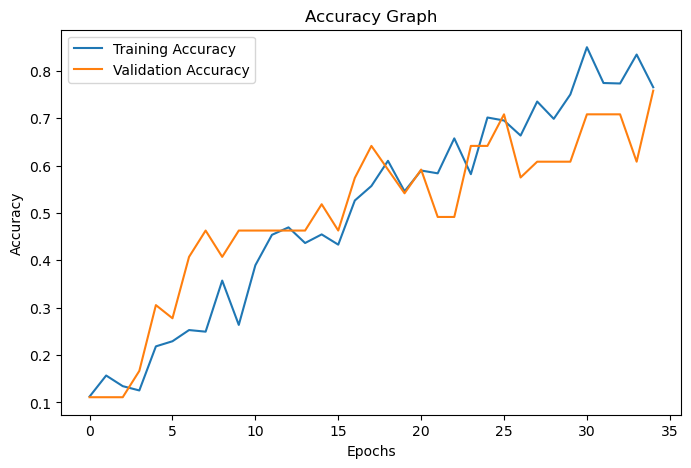

In [24]:
from SimpleCNN import SimpleCNN
import torch.optim as optim
import torch.nn as nn

model_CNN = SimpleCNN().to(device)
optimizer = optim.Adam(model_CNN.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

train(model=model_CNN, train_dataloader=train_dataloader, val_dataloader=val_dataloader, no_epochs=35, optimizer=optimizer, criterion=criterion)

1. Why the CNN achieves higher accuracy with potentially fewer parameters than a massive ANN. 

Here, we can see that our simple CNN model has performed better than the ANN's we trained previously with a fewer number of epochs. This is simply due to the fact that we are not destroying spatial information that the pixels of the image have during our Convulutional layer training process. This helps the model to learn about the features that would have been destroyed if would have flattened our image vectors which we did in our ANN architecture.

2. How the Filter/Kernel works to detect edges/shapes (The "Feature Map" concept). 

A convolution kernel is a small matrix of learnable weights that slides over the image and computes a dot product with local pixel values. The resulting values across all positions form a feature map, which indicates how strongly a specific pattern appears at each location. For example, an edge-detection filter produces high responses where pixel intensities change sharply, highlighting boundaries. As layers stack, simple edge detections combine into curves and shapes, allowing the network to represent meaningful structures instead of individual pixels.